This script is to construct a simple 2D underground model, that contains a mesh, with artificial dataset of a ground property (e.g. stiffness) and scale of fluctuation. 

In [1]:
import os
from pathlib import Path
import pyvista as pv
import matplotlib.pyplot as plt
import numpy as np
import vtk
from vtk.util.numpy_support import numpy_to_vtk
import scipy.stats as stats
import subprocess
import os
from pathlib import Path

In [2]:
import generate_random_field  
import Mesh_settings  

In the first step, we make some settings. 

To create a mesh, we set the size and number of cells of the mesh.

To assign a ground property (e.g. stiffness) to all the nodes of the mesh, we give the mean and variance for each layer.

If the parameter has a linear relationship with depth, we set the slope. 

To generate a random field, we set the scale of fluctuation. Random seed is to initiate a random field. Same seed can reproduce the same random field.

In [3]:
# import parameters from mesh_settings configuration file

filename = Mesh_settings.filename
width_of_boundary = Mesh_settings.width_of_boundary
depth_of_boundary = Mesh_settings.depth_of_boundary
number_of_cells_x = Mesh_settings.number_of_cells_x
number_of_cells_y = Mesh_settings.number_of_cells_y
number_of_layers = Mesh_settings.number_of_layers

stiffness_mean = Mesh_settings.stiffness_mean  # Pa 
slope = Mesh_settings.slope

horizontal_scale_of_fluctuation = Mesh_settings.horizontal_scale_of_fluctuation
vertical_scale_of_fluctuation = Mesh_settings.vertical_scale_of_fluctuation

We create a output directory. All generated files will be put there.

In [4]:
out_dir = Path(os.environ.get("OGS_TESTRUNNER_OUT_DIR", "_out"))
if not out_dir.exists():
    out_dir.mkdir(parents=True)

In [5]:
os.chdir(out_dir)
file = filename + '.vtu'

We make a mesh by running the command line by subprocess.

In [6]:
subprocess.run("generateStructuredMesh -e quad -o "  + file + " --lx " + str(width_of_boundary) + " --ly " + str(depth_of_boundary) 
               + " --nx " + str(number_of_cells_x) + " --ny " + str(number_of_cells_y) + " --oy " + str( - depth_of_boundary)  ) 

CompletedProcess(args='generateStructuredMesh -e quad -o domain.vtu --lx 10 --ly 60 --nx 10 --ny 60 --oy -60', returncode=0)

In [7]:
subprocess.run("identifySubdomains -m " + file  + " -s 1e-6 -f " + file)

CompletedProcess(args='identifySubdomains -m domain.vtu -s 1e-6 -f domain.vtu', returncode=0)

In [8]:
# pyvista settings

pv.set_plot_theme("document")
pv.set_jupyter_backend("static")

def show_mesh(mesh):
    plotter = pv.Plotter()
    plotter.add_mesh(mesh, show_edges=True)
    plotter.view_xy()
    plotter.add_axes()
    plotter.show_bounds(mesh, xtitle="x", ytitle="y")
    plotter.window_size = [400, 1200]
    plotter.show()

def show_mesh_3D(mesh):
    plotter = pv.Plotter()
    plotter.add_mesh(mesh, show_edges=True)
    plotter.add_axes()
    plotter.window_size = [800, 400]
    plotter.show()

Here we read the mesh file.

In [9]:
mesh = pv.read(file) # file
reader = vtk.vtkXMLUnstructuredGridReader()
reader.SetFileName(file) # file
reader.Update()  # Needed because of GetScalarRange
reader_data = reader.GetOutput()

We create a virtual stiffness parameter. 

For the case of constant layer, we just give a value, and repeat the number to all thcellser

For the case of depth linear dependent layer, we get mean to the cell at the middle 10). By using formulae, y=mc+x, i.e. stiffness = stiffness mean + slope factor * number of vertical cells, we can calculate stiffness at ecell.ted


In [10]:
repeat_number = int((width_of_boundary) * number_of_cells_y) 
depth_of_layer =  depth_of_boundary / number_of_layers

def constant_layer(m, r, hn, vcpl):
    layer = np.repeat(m, r).reshape(hn, vcpl)
    return layer

def depth_linear_dependent_layer (slope, m, hn, dl, vcpl):
    x = np.arange(-vcpl/2, vcpl/2)
    delta = -slope * (dl / vcpl)
    y = (m + x * delta)
    layer = np.repeat (y, hn).reshape(hn, vcpl, order='F')
    return layer

stiffness= depth_linear_dependent_layer(slope, stiffness_mean[0], number_of_cells_x, depth_of_layer, number_of_cells_y)

Here we import our random field.

In [11]:
total_rf = generate_random_field.stiff_field

We combine the ground property (trend) with random field.

In [12]:
stiffness_with_RF = np.add(stiffness, total_rf)

In [13]:
# Plot variogram

#ax= stiff_model.plot("variogram")
#stiff_model.plot("covariance",ax=ax)
#stiff_model.plot("correlation", ax=ax)

We add the above result into the mesh structure, and write a new mesh file.

In [14]:
# Add parameter to vtu
stiffness_1D_array =  stiffness_with_RF.flatten('F')
stiffness_node = numpy_to_vtk(stiffness_1D_array)
stiffness_node.SetName('Stiffness')
reader_data.GetCellData().AddArray(stiffness_node)
#reader_data.GetPointData().AddArray(stiffness_node)

vtu_with_stiffness =  filename + "_with_stiffness.vtu"

writer = vtk.vtkXMLUnstructuredGridWriter()
writer.SetInputData(reader_data)
writer.SetFileName(vtu_with_stiffness)
writer.Write()

1

In [15]:
print(os.getcwd())

c:\Users\glori\Documents\tasks\ogs_exercise\2D\_out


We read and plot the new mesh file. 

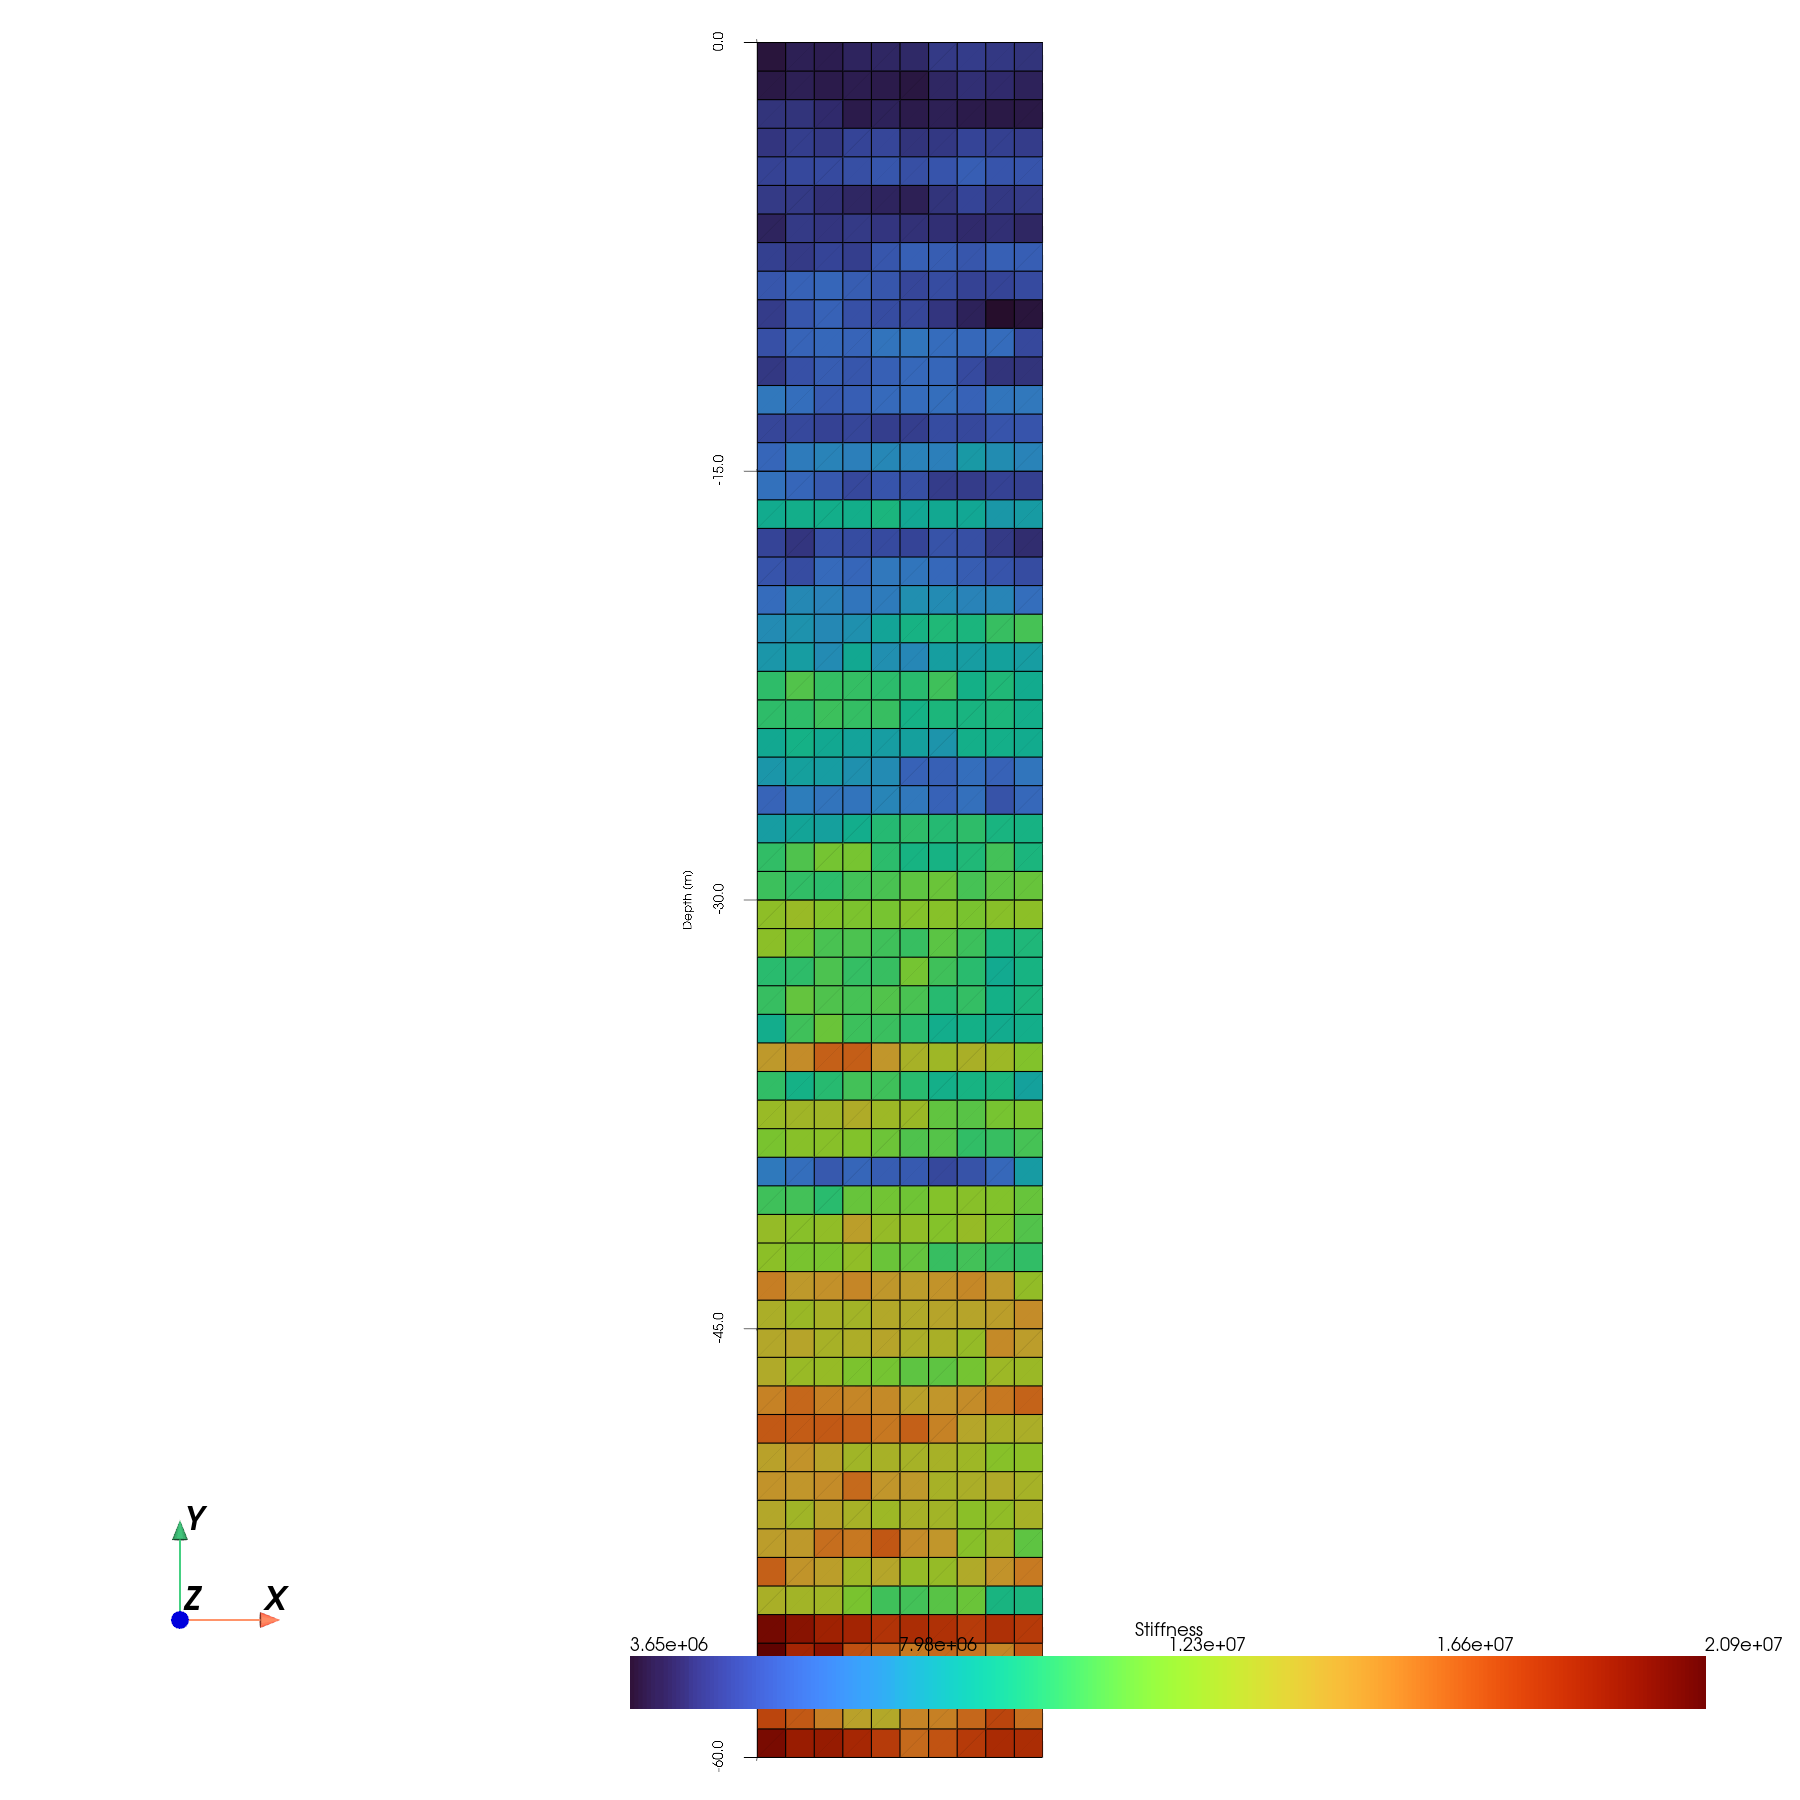

In [16]:
new_mesh = pv.read(vtu_with_stiffness)

pl = pv.Plotter()

pl.add_mesh(new_mesh,  scalars = "Stiffness", show_edges=True, cmap="turbo")
pl.view_xy()
pl.add_axes()
pl.window_size = [1800, 1800]

pl.show_grid(ytitle='Depth (m)', show_xaxis = False, show_xlabels =False, font_family ='arial', font_size=10, bold=False)

pl.show()


Here we draw a graph to visualize the change of stiffness parameter over depth. 

This is a graph taking the mid x-axis.

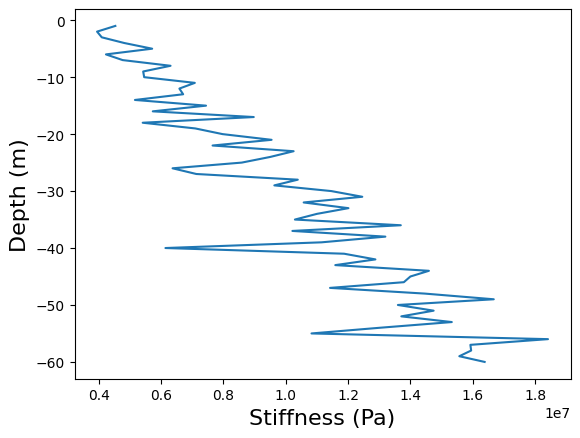

In [17]:
import matplotlib.pyplot as plt
import numpy as np

mid_axis = int(number_of_cells_x / 2)

xpoints = stiffness_with_RF[mid_axis, :]   # total_rf  to check detrended RF, stiffness to check trend
ypoints = np.arange (-depth_of_boundary, 0, 1)

plt.xlabel('Stiffness (Pa)', fontsize=16)
plt.ylabel('Depth (m)', fontsize=16)

plt.plot(xpoints, ypoints)
plt.show()

We get some value to examine.

In [ ]:
print ('stiffness at -30m', xpoints[-30])
print ('stiffness at -50m',xpoints[-50])
stiffness_with_RF.min()

stiffness at -30m 11459007.687427366
stiffness at -50m 13596492.324461788


This is a graph taking the mean of the x axis.

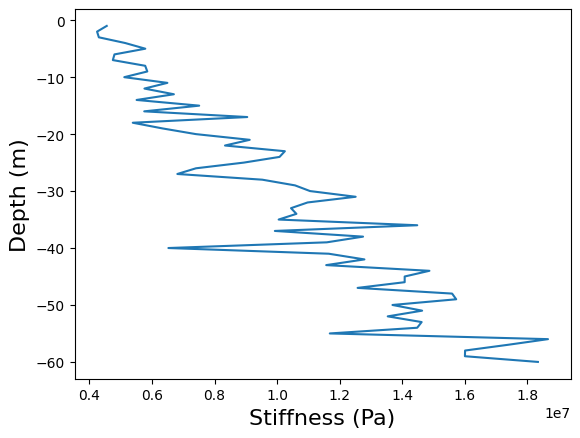

In [22]:
xpoints = np.mean(stiffness_with_RF, axis=0)   # total_rf  to check detrended RF, stiffness to check trend
ypoints = np.arange (-depth_of_boundary, 0, 1)

plt.xlabel('Stiffness (Pa)', fontsize=16)
plt.ylabel('Depth (m)', fontsize=16)

plt.plot(xpoints, ypoints)
plt.show()

In [19]:
os.chdir("..")

In [20]:
print(os.getcwd())

c:\Users\glori\Documents\tasks\ogs_exercise\2D
